## Importing All Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

## Importing Datasets

In [2]:
dataset_1 = pd.read_csv("emotion_dataset_raw.csv")
dataset_2 = pd.read_csv("combined_emotion.csv")

In [3]:
print(dataset_1.shape)
print(dataset_2.shape)

(34792, 2)
(422746, 2)


In [4]:
print(len(dataset_1))
print(len(dataset_2))

34792
422746


## Imporitng Libraries to preprocess data

In [5]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

## Dataset_1

In [6]:
copy_d1 = dataset_1.copy()

In [7]:
duplicates = copy_d1['Text'].duplicated()
print(duplicates)

0        False
1        False
2        False
3        False
4        False
         ...  
34787    False
34788    False
34789    False
34790    False
34791    False
Name: Text, Length: 34792, dtype: bool


In [8]:
duplicates = copy_d1['Text'].duplicated().sum()
print(duplicates)

3682


In [9]:
copy_d1 = copy_d1.drop_duplicates(subset=['Text'])
print(copy_d1)

        Emotion                                               Text
0       neutral                                             Why ? 
1           joy    Sage Act upgrade on my to do list for tommorow.
2       sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3           joy   Such an eye ! The true hazel eye-and so brill...
4           joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
...         ...                                                ...
34787  surprise  @MichelGW have you gift! Hope you like it! It'...
34788       joy  The world didnt give it to me..so the world MO...
34789     anger                           A man robbed me today . 
34790      fear  Youu call it JEALOUSY, I call it of #Losing YO...
34791   sadness  I think about you baby, and I dream about you ...

[31110 rows x 2 columns]


In [10]:
has_nan = copy_d1[['Text', 'Emotion']].isna().any()
print(has_nan)

Text       False
Emotion    False
dtype: bool


In [11]:

mask = copy_d1['Text'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'@\w+',  case=False, regex=True, na=False).sum()  
print(mask)
mask = copy_d1['Text'].str.contains(r'#\w+',  case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'&\w+;',  case=False, regex=True, na=False).sum()
print(mask)
mask = ~copy_d1['Text'].str.isascii()
print(mask.sum())

1454
5068
4267
2119
1421


In [12]:

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
HTML_TAGS = re.compile(r'\b(href|http|https|www|html|amp|nbsp)\w*\b')

def preprocess_1(text):

    text = text.lower()

    text = re.sub(r'#\w+', '', text)
    
  
    text = re.sub(r'@\w+', '', text)
    
    
    text = re.sub(r'&\w+', '', text)
    
             
    text = HTML_TAGS.sub(' ', text)   
    
  
    text = text.encode('ascii', 'ignore').decode('ascii')
    
  
    text = text.translate(str.maketrans('', '', string.punctuation))
    
 
    text = re.sub(r'\d+', '', text)
    

    text = re.sub(r'\s+', ' ', text).strip()
    
    
    tokens = word_tokenize(text)
    
   
    tokens = [t for t in tokens if t not in stop_words]
    
   
    tokens = [stemmer.stem(t) for t in tokens]
    
    
    return ' '.join(tokens)

In [13]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [14]:
copy_d1['Text'] = copy_d1['Text'].apply(preprocess_1)
print("done")

done


In [15]:
mask = copy_d1['Text'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'@\w+',  case=False, regex=True, na=False).sum()  
print(mask)
mask = copy_d1['Text'].str.contains(r'#\w+',  case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d1['Text'].str.contains(r'&\w+;',  case=False, regex=True, na=False).sum()
print(mask)
mask = ~copy_d1['Text'].str.isascii()
print(mask.sum())

316
0
0
0
0


In [16]:
print(copy_d1['Text'].isnull().sum())

print((copy_d1['Text'] == '').sum())


print(copy_d1[copy_d1['Text'] == ''])


copy_d1 = copy_d1[copy_d1['Text'] != '']
copy_d1 = copy_d1.reset_index(drop=True)

0
149
       Emotion Text
0      neutral     
76     neutral     
114    neutral     
269    neutral     
392    neutral     
...        ...  ...
34000  neutral     
34234  neutral     
34243  neutral     
34429  neutral     
34662  neutral     

[149 rows x 2 columns]


In [17]:
print((copy_d1['Text'] == '').sum())

0


In [18]:
mask = copy_d1['Text'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)

316


In [19]:
print("Original Dataset: " ,dataset_1.head(10))
print("Processed Dataset: " ,copy_d1.head(10))

Original Dataset:      Emotion                                               Text
0   neutral                                             Why ? 
1       joy    Sage Act upgrade on my to do list for tommorow.
2   sadness  ON THE WAY TO MY HOMEGIRL BABY FUNERAL!!! MAN ...
3       joy   Such an eye ! The true hazel eye-and so brill...
4       joy  @Iluvmiasantos ugh babe.. hugggzzz for u .!  b...
5      fear  I'm expecting an extremely important phonecall...
6   sadness   .Couldnt wait to see them live. If missing th...
7  surprise  maken Tip 2: Stop op een moment dat je het hel...
8  surprise  En dan krijg je ff een cadeautje van een tweep...
9  surprise   @1116am Drummer Boy bij op verzoek van @BiemO...
Processed Dataset:      Emotion                                               Text
0       joy                      sage act upgrad list tommorow
1   sadness  way homegirl babi funer man hate funer realli ...
2       joy  eye true hazel eyeand brilliant regular featur...
3       joy  ugh

In [20]:
print(copy_d1.shape)

(30961, 2)


In [21]:
duplicates = copy_d1['Text'].duplicated().sum()
print(duplicates)

678


In [22]:
copy_d1 = copy_d1.drop_duplicates(subset=['Text'])

In [23]:
duplicates = copy_d1['Text'].duplicated().sum()
print(duplicates)

0


In [24]:
print(copy_d1.shape)

(30283, 2)


## Dataset_2

In [25]:
copy_d2 = dataset_2.copy()

In [26]:
print(copy_d2)

                                                 sentence emotion
0           i just feel really helpless and heavy hearted    fear
1       ive enjoyed being able to slouch about relax a...     sad
2       i gave up my internship with the dmrg and am f...    fear
3                              i dont know i feel so lost     sad
4       i am a kindergarten teacher and i am thoroughl...    fear
...                                                   ...     ...
422741                 i begun to feel distressed for you    fear
422742  i left feeling annoyed and angry thinking that...   anger
422743  i were to ever get married i d have everything...     joy
422744  i feel reluctant in applying there because i w...    fear
422745  i just wanted to apologize to you because i fe...   anger

[422746 rows x 2 columns]


In [27]:
duplicates = copy_d2['sentence'].duplicated()
print(duplicates)

0         False
1         False
2         False
3         False
4         False
          ...  
422741     True
422742     True
422743     True
422744     True
422745     True
Name: sentence, Length: 422746, dtype: bool


In [28]:
duplicates = copy_d2['sentence'].duplicated().sum()
print(duplicates)

28924


In [29]:
copy_d2 = copy_d2.drop_duplicates(subset=['sentence'])

In [30]:
has_nan = copy_d2[['sentence', 'emotion']].isna().any()
print(has_nan)

sentence    False
emotion     False
dtype: bool


In [31]:
mask = copy_d2['sentence'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d2['sentence'].str.contains(r'@\w+',  case=False, regex=True, na=False).sum()  
print(mask)
mask = copy_d2['sentence'].str.contains(r'#\w+',  case=False, regex=True, na=False).sum()
print(mask)
mask = copy_d2['sentence'].str.contains(r'&\w+;',  case=False, regex=True, na=False).sum()
print(mask)
mask = ~copy_d2['sentence'].str.isascii()
print(mask.sum())

9244
0
0
0
0


In [32]:

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
HTML_TAGS = re.compile(r'\b(href|http|https|www|html|amp|nbsp)\w*\b')

def preprocess_2(text):
  
    text = text.lower()
    
             
    text = HTML_TAGS.sub(' ', text)   
    
  
    text = text.translate(str.maketrans('', '', string.punctuation))
  
    text = re.sub(r'\d+', '', text)
    
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    
    tokens = word_tokenize(text)
    
    
    tokens = [t for t in tokens if t not in stop_words]
    
 
    tokens = [stemmer.stem(t) for t in tokens]
    
 
    return ' '.join(tokens)

In [33]:
copy_d2['sentence'] = copy_d2['sentence'].apply(preprocess_2)
print("done")

done


In [34]:
mask = copy_d2['sentence'].str.contains(r'href|http|https|www|html|amp|nbsp', case=False, regex=True, na=False).sum()
print(mask)

2008


In [35]:
print(copy_d2['sentence'].isnull().sum())

print((copy_d2['sentence'] == '').sum())


0
9


In [36]:

copy_d2 = copy_d2[copy_d2['sentence'] != '']
copy_d2 = copy_d2.reset_index(drop=True)

In [37]:
print((copy_d2['sentence'] == '').sum())

0


In [38]:
print("Original Dataset: " ,dataset_2.head(10))
print("Processed Dataset: " ,copy_d2.head(10))

Original Dataset:                                              sentence  emotion
0      i just feel really helpless and heavy hearted     fear
1  ive enjoyed being able to slouch about relax a...      sad
2  i gave up my internship with the dmrg and am f...     fear
3                         i dont know i feel so lost      sad
4  i am a kindergarten teacher and i am thoroughl...     fear
5         i was beginning to feel quite disheartened      sad
6  i would think that whomever would be lucky eno...     love
7  i fear that they won t ever feel that deliciou...      joy
8  im forever taking some time out to have a lie ...  suprise
9  i can still lose the weight without feeling de...      sad
Processed Dataset:                                              sentence  emotion
0                   feel realli helpless heavi heart     fear
1  ive enjoy abl slouch relax unwind frankli need...      sad
2               gave internship dmrg feel distraught     fear
3                              

In [39]:
print(copy_d2.shape)

(393813, 2)


In [40]:
duplicates = copy_d2['sentence'].duplicated().sum()
print(duplicates)

14002


In [41]:
copy_d2 = copy_d2.drop_duplicates(subset=['sentence'])

In [42]:
duplicates = copy_d2['sentence'].duplicated().sum()
print(duplicates)

0


In [43]:
print(copy_d2.shape)

(379811, 2)


## Nahian - Naive Bayes - Multinomial Naive Bayes

## Dataset_1

In [44]:
XN_1 = copy_d1['Text']
YN_1 = copy_d1['Emotion']

In [45]:
from sklearn.model_selection import train_test_split
XN1_train, XN1_test, YN1_train, YN1_test = train_test_split(XN_1, YN_1, test_size=0.2, random_state=42, stratify=YN_1)

## Bag of Words

In [46]:
Bag_o_w = CountVectorizer()
XN_train_bow = Bag_o_w.fit_transform(XN1_train)
XN_test_bow = Bag_o_w.transform(XN1_test)

In [47]:
MNB_BW = MultinomialNB()
MNB_BW.fit(XN_train_bow, YN1_train)

predictions_BW = MNB_BW.predict(XN_test_bow)
print("Accuracy score: ", accuracy_score(YN1_test, predictions_BW))
print("Precision: ", precision_score(YN1_test, predictions_BW, average='weighted'))
print("Recall: ", recall_score(YN1_test, predictions_BW, average='weighted'))
print("F1 Score: ", f1_score(YN1_test, predictions_BW, average='weighted'))

Accuracy score:  0.5563810467228001
Precision:  0.5848819678792966
Recall:  0.5563810467228001
F1 Score:  0.5212632964009482


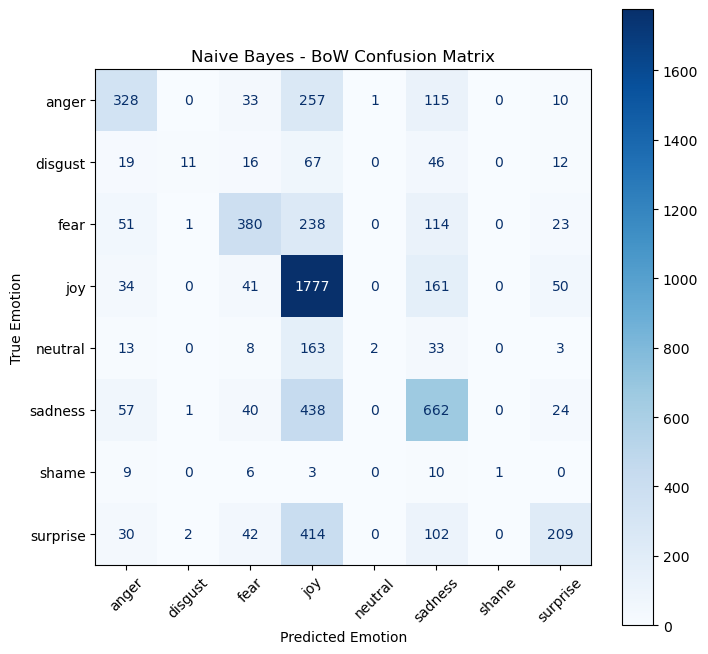

In [48]:
emo_labels = sorted(YN1_test.unique())
NBcm_bow = confusion_matrix(YN1_test, predictions_BW, labels=emo_labels)
NBcm_display_bow = ConfusionMatrixDisplay(confusion_matrix=NBcm_bow, display_labels=emo_labels)

fig, ax = plt.subplots(figsize=(8, 8))
NBcm_display_bow.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Naive Bayes - BoW Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

## TF-IDF

In [49]:
TF_IDF_c = TfidfVectorizer()
XN_train_TFIDF = TF_IDF_c.fit_transform(XN1_train)
XN_test_TFIDF = TF_IDF_c.transform(XN1_test)

In [50]:
MNB_TFIDF = MultinomialNB()
MNB_TFIDF.fit(XN_train_TFIDF, YN1_train)

predictions_TFIDF = MNB_TFIDF.predict(XN_test_TFIDF)
print("Accuracy score: ", accuracy_score(YN1_test, predictions_TFIDF))
print("Precision: ", precision_score(YN1_test, predictions_TFIDF, average='weighted'))
print("Recall: ", recall_score(YN1_test, predictions_TFIDF, average='weighted'))
print("F1 Score: ", f1_score(YN1_test, predictions_TFIDF, average='weighted'))

Accuracy score:  0.47036486709592207
Precision:  0.5820018828221848
Recall:  0.47036486709592207
F1 Score:  0.4019746575054667


D:\NLP\NLP Project\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [51]:
from collections import Counter

print("Actual classes:")
print(Counter(YN1_test))

print("\nPredicted classes:")
print(Counter(predictions_TFIDF))

Actual classes:
Counter({'joy': 2063, 'sadness': 1222, 'fear': 807, 'surprise': 799, 'anger': 744, 'neutral': 222, 'disgust': 171, 'shame': 29})

Predicted classes:
Counter({np.str_('joy'): 4837, np.str_('sadness'): 684, np.str_('fear'): 220, np.str_('surprise'): 189, np.str_('anger'): 127})


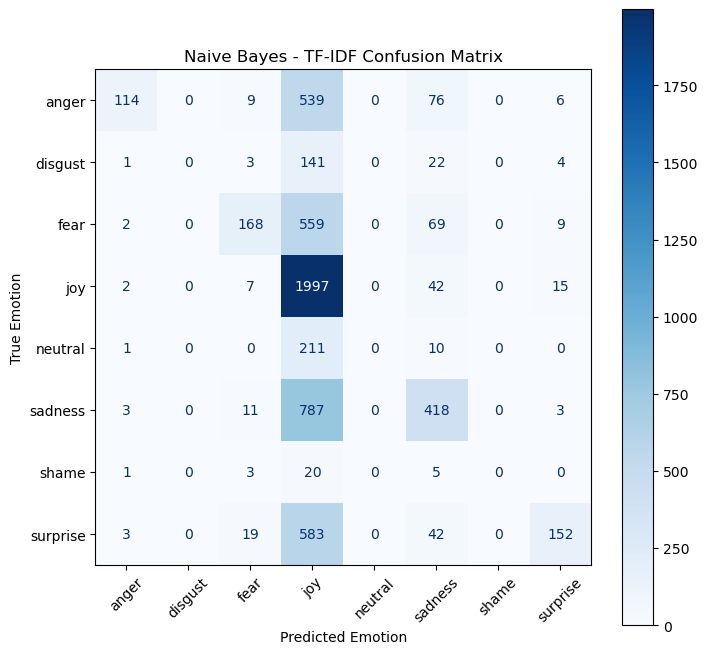

In [52]:
emo_labels = sorted(YN1_test.unique())
NBcm_tfidf = confusion_matrix(YN1_test, predictions_TFIDF, labels=emo_labels)
NBcm_display_tfidf = ConfusionMatrixDisplay(confusion_matrix=NBcm_tfidf, display_labels=emo_labels)

fig, ax = plt.subplots(figsize=(8, 8))
NBcm_display_tfidf.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Naive Bayes - TF-IDF Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

# Tonmoy

# Splitting dataset_2 train(80%)-test(20%)

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [54]:
xt = copy_d2["sentence"]
yt = copy_d2["emotion"]

In [55]:
xt_train, xt_test, yt_train, yt_test = train_test_split(
    xt,
    yt,
    test_size = 0.2,
    random_state=42,
    stratify=yt
)

# Bag of Words

In [56]:
bow = CountVectorizer()
xt_train_bow = bow.fit_transform(xt_train)
xt_test_bow = bow.transform(xt_test)

In [57]:
MNB_BW = MultinomialNB()
MNB_BW.fit(xt_train_bow, yt_train)

yt_pred_bow = MNB_BW.predict(xt_test_bow)

# TF-IDF

In [58]:
tfidf = TfidfVectorizer()
xt_train_tfidf = tfidf.fit_transform(xt_train)
xt_test_tfidf = tfidf.transform(xt_test)

In [59]:
MNB_TFIDF = MultinomialNB()
MNB_TFIDF.fit(xt_train_tfidf, yt_train)

yt_pred_tfidf = MNB_TFIDF.predict(xt_test_tfidf)

# Naive Bayes

# Evaluation

In [60]:
accuracy_bow = accuracy_score(yt_test, yt_pred_bow)
accuracy_tfidf = accuracy_score(yt_test, yt_pred_tfidf)

In [61]:
precision_bow = precision_score(yt_test, yt_pred_bow, average='weighted')
precision_tfidf = precision_score(yt_test, yt_pred_tfidf, average='weighted')

In [62]:
recall_bow = recall_score(yt_test, yt_pred_bow, average='weighted')
recall_tfidf = recall_score(yt_test, yt_pred_tfidf, average='weighted')

In [63]:
f1_bow = f1_score(yt_test, yt_pred_bow, average='weighted')
f1_tfidf = f1_score(yt_test, yt_pred_tfidf, average='weighted')

In [64]:
print("Using Bag of Words:")
print(f"Accuracy:{accuracy_bow:.2%}")
print(f"Precision:{precision_bow:.2%}")
print(f"Recall:{recall_bow:.2%}")
print(f"F1-Score:{f1_bow:.2%}")

print("\nUsing TF-IDF:")
print(f"Accuracy:{accuracy_tfidf:.2%}")
print(f"Precision:{precision_tfidf:.2%}")
print(f"Recall:{recall_tfidf:.2%}")
print(f"F1-Score:{f1_tfidf:.2%}")

Using Bag of Words:
Accuracy:85.89%
Precision:86.13%
Recall:85.89%
F1-Score:85.25%

Using TF-IDF:
Accuracy:75.84%
Precision:80.76%
Recall:75.84%
F1-Score:72.59%


# Confusion Matrix

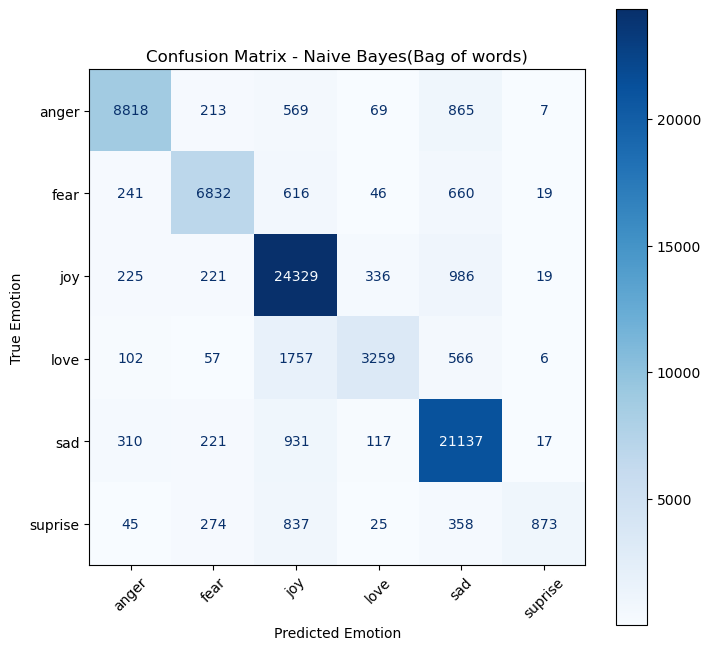

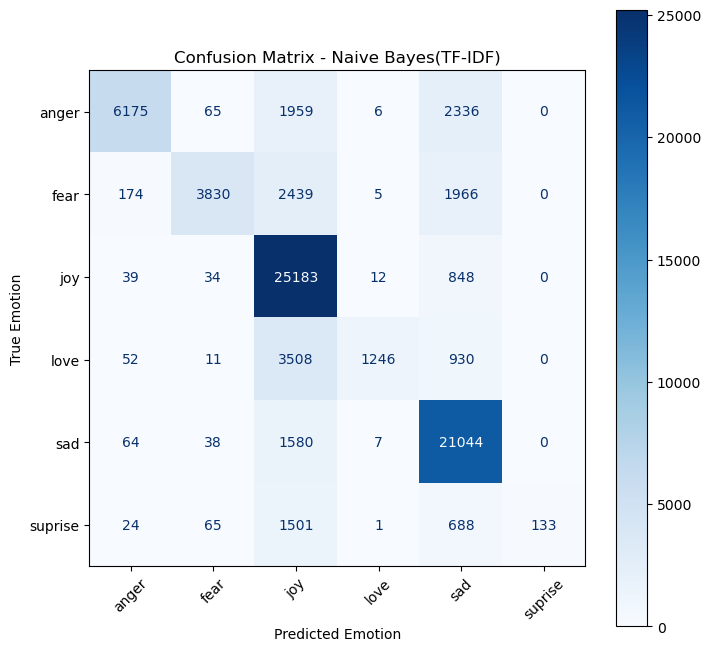

In [65]:
emo_labels = sorted(copy_d2["emotion"].unique())
cm_bow = confusion_matrix(yt_test, yt_pred_bow, labels=emo_labels)
disp_bow = ConfusionMatrixDisplay(confusion_matrix=cm_bow, display_labels=emo_labels)
fig, ax = plt.subplots(figsize = (8, 8))
disp_bow.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Naive Bayes(Bag of words)")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

cm_tfidf = confusion_matrix(yt_test, yt_pred_tfidf, labels=emo_labels)
disp_tfidf = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf, display_labels=emo_labels)
fig, ax = plt.subplots(figsize=(8, 8))
disp_tfidf.plot(ax = ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Naive Bayes(TF-IDF)")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

# Splitting dataset_1 train(80%)-test(20%)

In [66]:
x = copy_d1["Text"]
y = copy_d1["Emotion"]

In [67]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Bag of Words

In [68]:
bow = CountVectorizer()
x_train_bow = bow.fit_transform(x_train)
x_test_bow = bow.transform(x_test)

# TF-IDF

In [69]:
tfidf = TfidfVectorizer()
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

# Logistic Regression

In [70]:

lr_bow = LogisticRegression(max_iter=1000, random_state=42)
lr_bow.fit(x_train_bow, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [71]:
lr_tfidf = LogisticRegression(max_iter=1000, random_state=42)
lr_tfidf.fit(x_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [72]:
y_pred_bow = lr_bow.predict(x_test_bow)
y_pred_tfidf = lr_tfidf.predict(x_test_tfidf)

# Evaluation

In [73]:
accuracy_bow = accuracy_score(y_test, y_pred_bow)
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

In [74]:
precision_bow = precision_score(
    y_test,
    y_pred_bow,
    average = "weighted"
)
precision_tfidf = precision_score(
    y_test,
    y_pred_tfidf,
    average = "weighted"
)

In [75]:
recall_bow = recall_score(
    y_test,
    y_pred_bow,
    average = "weighted"
)
recall_tfidf = recall_score(
    y_test,
    y_pred_tfidf,
    average = "weighted"
)

In [76]:
f1_bow = f1_score(
    y_test,
    y_pred_bow,
    average = "weighted"
)
f1_tfidf = f1_score(
    y_test,
    y_pred_tfidf,
    average = "weighted"
)

In [77]:
print("Using Bag of Words:")
print(f"Accuracy:{accuracy_bow:.2%}")
print(f"Precision:{precision_bow:.2%}")
print(f"Recall:{recall_bow:.2%}")
print(f"F1-Score:{f1_bow:.2%}")
print("\nUsing TF-IDF:")
print(f"Accuracy:{accuracy_tfidf:.2%}")
print(f"Precision:{precision_tfidf:.2%}")
print(f"Recall:{recall_tfidf:.2%}")
print(f"F1-Score:{f1_tfidf:.2%}")

Using Bag of Words:
Accuracy:58.40%
Precision:57.88%
Recall:58.40%
F1-Score:57.33%

Using TF-IDF:
Accuracy:58.28%
Precision:59.29%
Recall:58.28%
F1-Score:55.94%


# Confusion Matrix

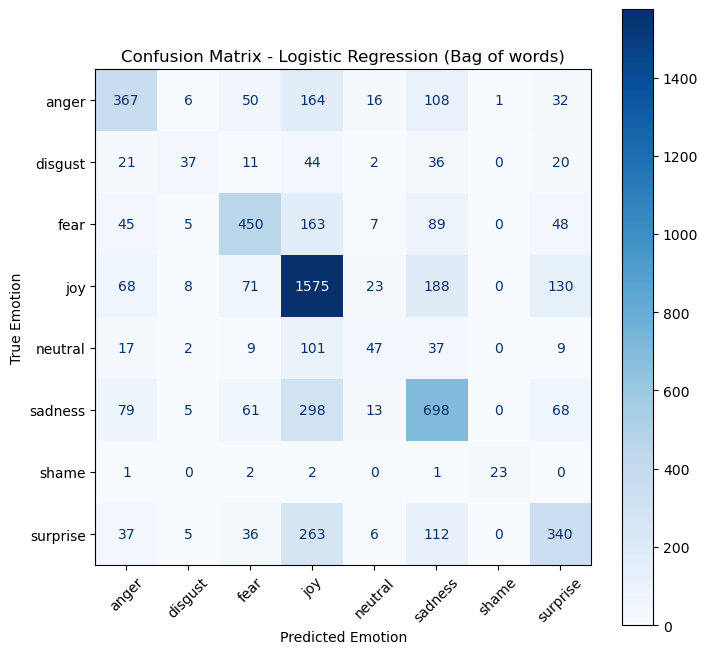

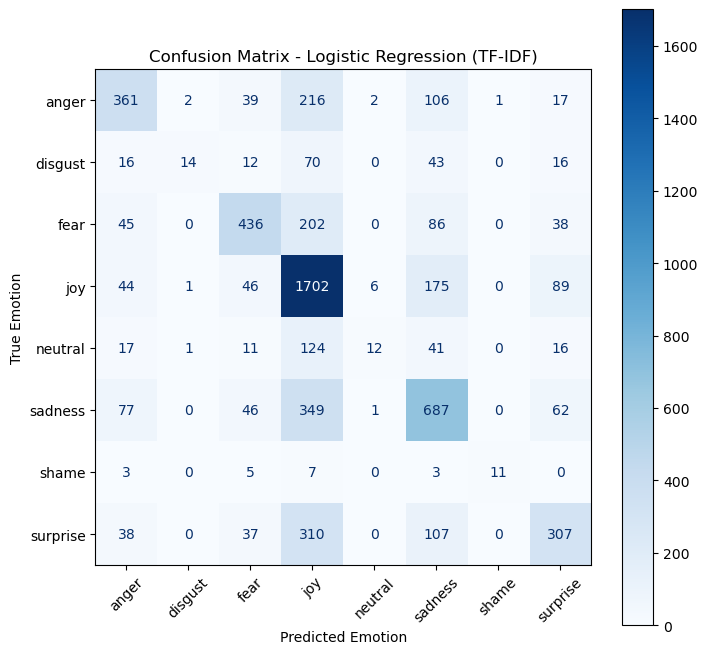

In [78]:
emo_labels = sorted(copy_d1["Emotion"].unique())
cm_bow = confusion_matrix(y_test, y_pred_bow, labels=emo_labels)
disp_bow = ConfusionMatrixDisplay(confusion_matrix=cm_bow, display_labels=emo_labels)
fig, ax = plt.subplots(figsize = (8, 8))
disp_bow.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Logistic Regression (Bag of words)")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

cm_tfidf = confusion_matrix(y_test, y_pred_tfidf, labels=emo_labels)
disp_tfidf = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf, display_labels=emo_labels)
fig, ax = plt.subplots(figsize=(8, 8))
disp_tfidf.plot(ax = ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Logistic Regression (TF-IDF)")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

# Samrat

# Splitting dataset_1 train(80%)-test(20%)

In [79]:
from sklearn.model_selection import train_test_split

In [80]:
x = copy_d1["Text"]
y = copy_d1["Emotion"]

In [81]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

# Bag of Words

In [82]:
bow = CountVectorizer()
x_train_bow = bow.fit_transform(x_train)
x_test_bow = bow.transform(x_test)

# TF-IDF

In [83]:
tfidf = TfidfVectorizer()
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

# Linear Support Vector Classifier(SVC)

In [84]:
svc_bow = LinearSVC(random_state=42)
svc_tfidf = LinearSVC(random_state=42)

In [85]:
svc_bow.fit(x_train_bow, y_train)
svc_tfidf.fit(x_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [86]:
y_pred_bow = svc_bow.predict(x_test_bow)
y_pred_tfidf = svc_tfidf.predict(x_test_tfidf)

# Evaluation

In [87]:
accuracy_bow = accuracy_score(y_test, y_pred_bow)
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

In [88]:
precision_bow = precision_score(
    y_test,
    y_pred_bow,
    average = "weighted"
)
precision_tfidf = precision_score(
    y_test,
    y_pred_tfidf,
    average = "weighted"
)

In [89]:
recall_bow = recall_score(
    y_test,
    y_pred_bow,
    average = "weighted"
)
recall_tfidf = recall_score(
    y_test,
    y_pred_tfidf,
    average = "weighted"
)

In [90]:
f1_bow = f1_score(
    y_test,
    y_pred_bow,
    average = "weighted"
)
f1_tfidf = f1_score(
    y_test,
    y_pred_tfidf,
    average = "weighted"
)

In [91]:
print("Using Bag of Words:")
print(f"Accuracy:{accuracy_bow:.2%}")
print(f"Precision:{precision_bow:.2%}")
print(f"Recall:{recall_bow:.2%}")
print(f"F1-Score:{f1_bow:.2%}")
print("\nUsing TF-IDF:")
print(f"Accuracy:{accuracy_tfidf:.2%}")
print(f"Precision:{precision_tfidf:.2%}")
print(f"Recall:{recall_tfidf:.2%}")
print(f"F1-Score:{f1_tfidf:.2%}")

Using Bag of Words:
Accuracy:56.13%
Precision:55.74%
Recall:56.13%
F1-Score:55.73%

Using TF-IDF:
Accuracy:58.11%
Precision:57.34%
Recall:58.11%
F1-Score:57.11%


# Confusion Matrix

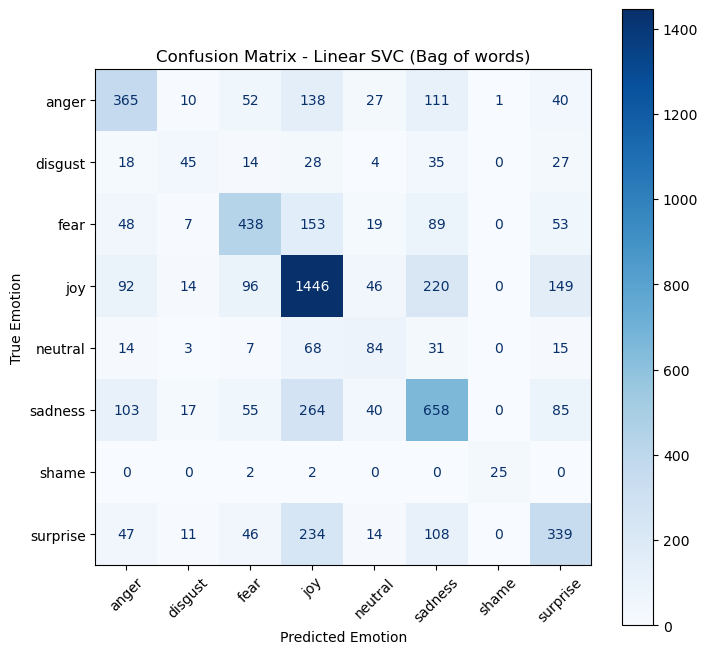

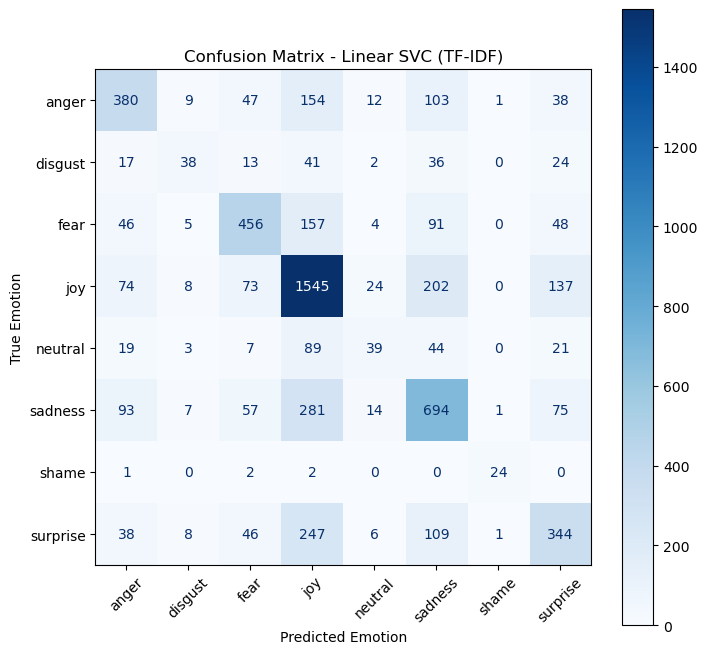

In [92]:
emo_labels = sorted(copy_d1["Emotion"].unique())
cm_bow = confusion_matrix(y_test, y_pred_bow, labels=emo_labels)
disp_bow = ConfusionMatrixDisplay(confusion_matrix=cm_bow, display_labels=emo_labels)
fig, ax = plt.subplots(figsize = (8, 8))
disp_bow.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Linear SVC (Bag of words)")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

cm_tfidf = confusion_matrix(y_test, y_pred_tfidf, labels=emo_labels)
disp_tfidf = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf, display_labels=emo_labels)
fig, ax = plt.subplots(figsize=(8, 8))
disp_tfidf.plot(ax = ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Linear SVC (TF-IDF)")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

# Splitting dataset_2 train(80%)-test(20%)

In [93]:
x = copy_d2["sentence"]
y = copy_d2["emotion"]

In [94]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Bag of Words

In [95]:
bow = CountVectorizer()
x_train_bow = bow.fit_transform(x_train)
x_test_bow = bow.transform(x_test)

# TF-IDF

In [96]:
tfidf = TfidfVectorizer()
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

# Logistic Regression

In [97]:
lr_bow = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_tfidf = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [98]:
lr_bow.fit(x_train_bow, y_train)
lr_tfidf.fit(x_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [99]:
y_pred_bow = lr_bow.predict(x_test_bow)
y_pred_tfidf = lr_tfidf.predict(x_test_tfidf)

# Evaluation

In [100]:
accuracy_bow = accuracy_score(y_test, y_pred_bow)
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

In [101]:
precision_bow = precision_score(
    y_test,
    y_pred_bow,
    average = "weighted"
)
precision_tfidf = precision_score(
    y_test,
    y_pred_tfidf,
    average = "weighted"
)

In [102]:
recall_bow = recall_score(
    y_test,
    y_pred_bow,
    average = "weighted"
)
recall_tfidf = recall_score(
    y_test,
    y_pred_tfidf,
    average = "weighted"
)

In [103]:
f1_bow = f1_score(
    y_test,
    y_pred_bow,
    average = "weighted"
)
f1_tfidf = f1_score(
    y_test,
    y_pred_tfidf,
    average = "weighted"
)

In [104]:
print("Using Bag of Words:")
print(f"Accuracy:{accuracy_bow:.2%}")
print(f"Precision:{precision_bow:.2%}")
print(f"Recall:{recall_bow:.2%}")
print(f"F1-Score:{f1_bow:.2%}")
print("\nUsing TF-IDF:")
print(f"Accuracy:{accuracy_tfidf:.2%}")
print(f"Precision:{precision_tfidf:.2%}")
print(f"Recall:{recall_tfidf:.2%}")
print(f"F1-Score:{f1_tfidf:.2%}")

Using Bag of Words:
Accuracy:90.42%
Precision:90.40%
Recall:90.42%
F1-Score:90.40%

Using TF-IDF:
Accuracy:90.32%
Precision:90.25%
Recall:90.32%
F1-Score:90.26%


# Confusion Matrix

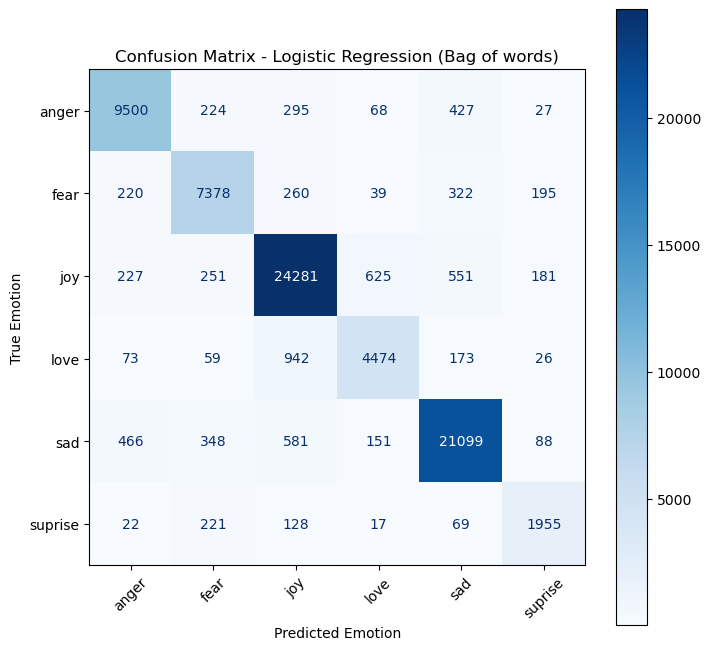

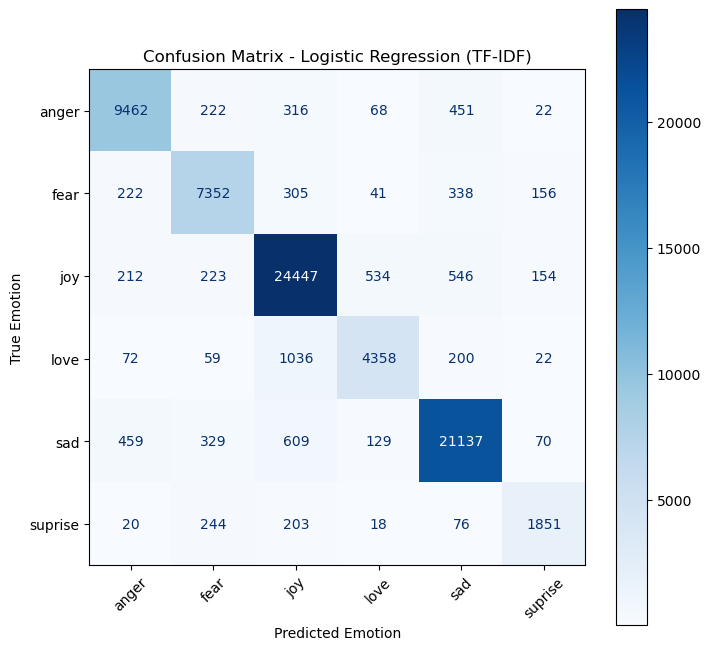

In [105]:
emo_labels = sorted(copy_d2["emotion"].unique())
cm_bow = confusion_matrix(y_test, y_pred_bow, labels=emo_labels)
disp_bow = ConfusionMatrixDisplay(confusion_matrix=cm_bow, display_labels=emo_labels)
fig, ax = plt.subplots(figsize = (8, 8))
disp_bow.plot(ax=ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Logistic Regression (Bag of words)")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

cm_tfidf = confusion_matrix(y_test, y_pred_tfidf, labels=emo_labels)
disp_tfidf = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf, display_labels=emo_labels)
fig, ax = plt.subplots(figsize=(8, 8))
disp_tfidf.plot(ax = ax, cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix - Logistic Regression (TF-IDF)")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.show()

# Nabil

## Support Vector Machine (Linear SVC)

### Dataset 2

In [106]:
X_2 = copy_d2['sentence']
y_2 = copy_d2['emotion']

X2_train, X2_test, y2_train, y2_test = train_test_split(X_2, y_2, test_size=0.2, random_state=42, stratify=y_2)

#### Bag of Words

In [107]:
bow_2 = CountVectorizer()
X2_train_bow = bow_2.fit_transform(X2_train)
X2_test_bow = bow_2.transform(X2_test)

svm_2_bow = LinearSVC()
svm_2_bow.fit(X2_train_bow, y2_train)
pred_2_bow = svm_2_bow.predict(X2_test_bow)

print("Accuracy: ", accuracy_score(y2_test, pred_2_bow))
print("Precision: ", precision_score(y2_test, pred_2_bow, average='weighted'))
print("Recall: ", recall_score(y2_test, pred_2_bow, average='weighted'))
print("F1 Score: ", f1_score(y2_test, pred_2_bow, average='weighted'))

Accuracy:  0.9037294472308888
Precision:  0.9034395340252249
Recall:  0.9037294472308888
F1 Score:  0.9034708529643645


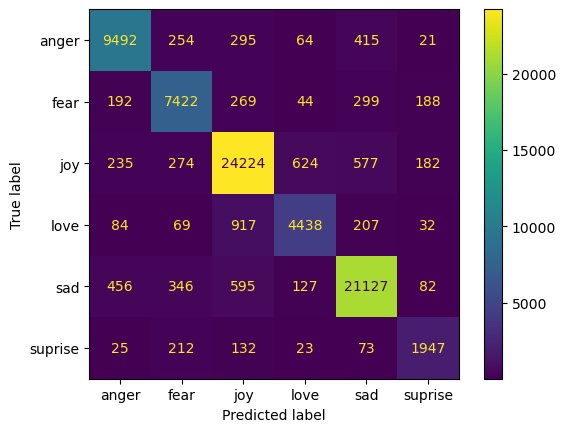

In [108]:
cm_2_bow = confusion_matrix(y2_test, pred_2_bow)
disp_2_bow = ConfusionMatrixDisplay(confusion_matrix=cm_2_bow, display_labels=svm_2_bow.classes_)
disp_2_bow.plot()
plt.show()

#### TF-IDF

In [109]:
tfidf_2 = TfidfVectorizer()
X2_train_tfidf = tfidf_2.fit_transform(X2_train)
X2_test_tfidf = tfidf_2.transform(X2_test)

svm_2_tfidf = LinearSVC()
svm_2_tfidf.fit(X2_train_tfidf, y2_train)
pred_2_tfidf = svm_2_tfidf.predict(X2_test_tfidf)

print("Accuracy: ", accuracy_score(y2_test, pred_2_tfidf))
print("Precision: ", precision_score(y2_test, pred_2_tfidf, average='weighted'))
print("Recall: ", recall_score(y2_test, pred_2_tfidf, average='weighted'))
print("F1 Score: ", f1_score(y2_test, pred_2_tfidf, average='weighted'))

Accuracy:  0.906941537327383
Precision:  0.9064632931987588
Recall:  0.906941537327383
F1 Score:  0.906499234000669


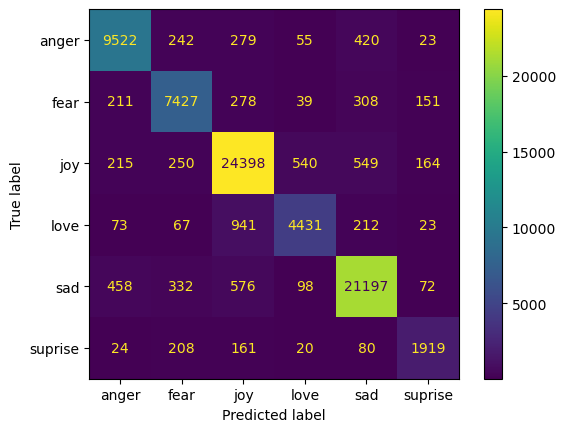

In [110]:
cm_2_tfidf = confusion_matrix(y2_test, pred_2_tfidf)
disp_2_tfidf = ConfusionMatrixDisplay(confusion_matrix=cm_2_tfidf, display_labels=svm_2_tfidf.classes_)
disp_2_tfidf.plot()
plt.show()